# EDA — Street Photo Scorer
Exploratory analysis of scraped posts and score distribution.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open('../data/raw/posts.json') as f:
    posts = json.load(f)

df = pd.DataFrame(posts)
print(df.shape)
df.head()

(492, 10)


,id,title,score,upvote_ratio,num_comments,created_utc,author,url,source,local_path
0,18vjnvx,Market of Sweethearts,2,0.75,0,1704064545,Klutzy_Deal3396,https://i.redd.it/9w2jq4hsqp9c1.jpeg,direct,data/raw/images/18vjnvx.jpeg
1,18vjn0m,Random collection of some photos I’ve taken re...,76,0.91,8,1704064471,Deltazip,https://i.redd.it/0jgqlhmjqp9c1.jpg,gallery,data/raw/images/18vjn0m.jpg
2,18vjgjj,Osaka Takoyaki,7,0.82,0,1704063877,Davethephotoguy,https://i.redd.it/dyvqs51qop9c1.jpeg,direct,data/raw/images/18vjgjj.jpeg
3,18vhug4,Last photo walk of 2023. Feels good to be back...,67,0.96,0,1704058898,IddyBiddyChuck,https://i.redd.it/zh26g85y9p9c1.jpg,gallery,data/raw/images/18vhug4.jpg
4,18vhj0u,"Quite proud of my Marseilles photo, whatchu th...",16,1.00,0,1704057940,666CroissantAuBeurre,https://i.redd.it/s7jndpd57p9c1.jpeg,direct,data/raw/images/18vhj0u.jpeg


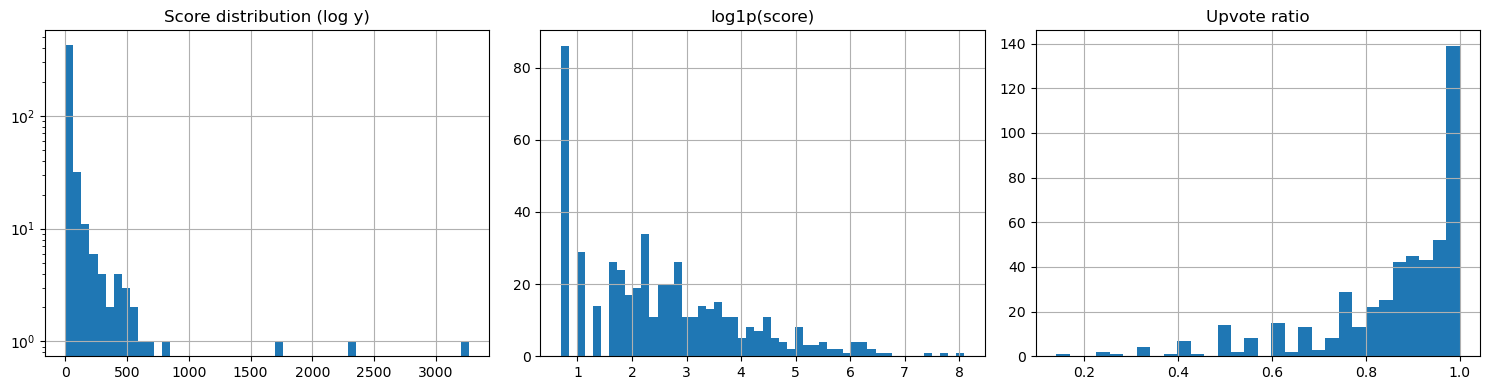

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['score'].hist(bins=50, ax=axes[0], log=True); axes[0].set_title('Score distribution (log y)')
np.log1p(df['score']).hist(bins=50, ax=axes[1]); axes[1].set_title('log1p(score)')
df['upvote_ratio'].hist(bins=30, ax=axes[2]); axes[2].set_title('Upvote ratio')
plt.tight_layout()

In [3]:
print(df[['score', 'upvote_ratio', 'num_comments']].describe())

             score  upvote_ratio  num_comments
count   492.000000    492.000000    492.000000
mean     54.556911      0.857114      4.997967
std     214.692550      0.162570     14.751506
min       1.000000      0.140000      0.000000
25%       3.000000      0.790000      0.000000
50%       9.000000      0.910000      0.000000
75%      30.000000      0.980000      3.000000
max    3267.000000      1.000000    173.000000


## Score vs comments correlation

Text(0.5, 1.0, 'Score vs Comments')

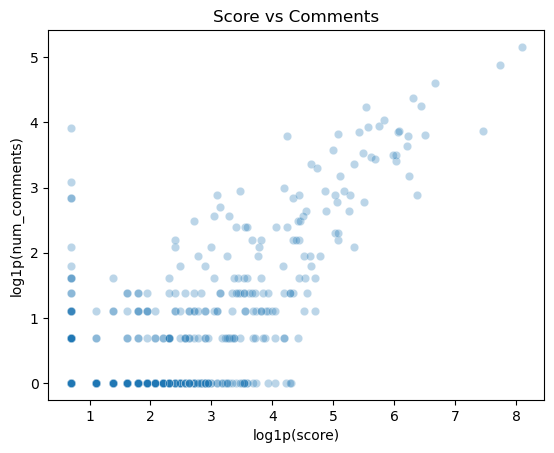

In [4]:
sns.scatterplot(data=df, x=np.log1p(df['score']), y=np.log1p(df['num_comments']), alpha=0.3)
plt.xlabel('log1p(score)'); plt.ylabel('log1p(num_comments)')
plt.title('Score vs Comments')